# 05 — Model Evaluation

Deep evaluation of trained models:
- Confusion matrices
- Classification reports
- Calibration reliability diagrams
- Time-series cross-validation
- Prediction distribution analysis

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, log_loss, brier_score_loss,
)
from sklearn.model_selection import TimeSeriesSplit
import warnings
warnings.filterwarnings('ignore')

from mls_predictor.data_loader import load_raw_data
from mls_predictor.elo import compute_elo_history
from mls_predictor.feature_engine import build_all_features, get_feature_columns
from mls_predictor.model_utils import (
    temporal_train_test_split, prepare_features,
    train_all_models, evaluate_models, build_ensemble_predictions,
)

In [2]:
%%time
df = load_raw_data()
df = compute_elo_history(df)
df_feat = build_all_features(df)
feature_cols = get_feature_columns()['all']

split = temporal_train_test_split(df_feat, 'target_1x2', feature_cols)
X_train, X_test, imputer, scaler = prepare_features(split['X_train'], split['X_test'])
models = train_all_models(X_train, split['y_train'].values, '1x2')

CPU times: total: 1min 54s
Wall time: 1min 29s


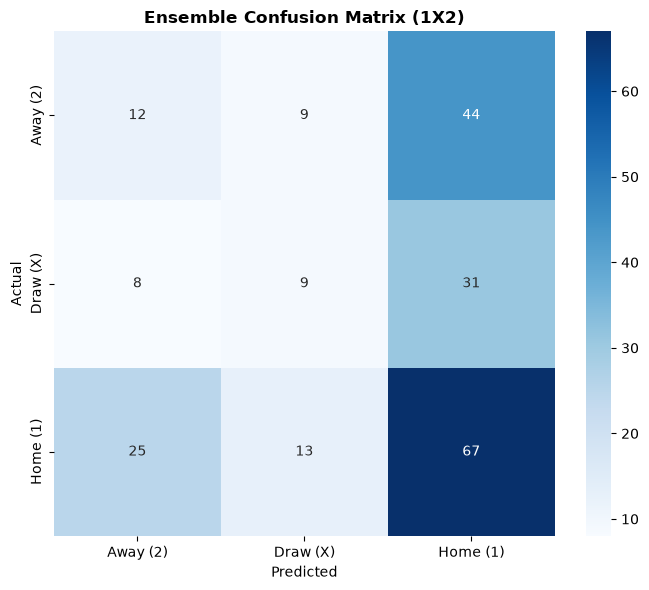

              precision    recall  f1-score   support

    Away (2)       0.27      0.18      0.22        65
    Draw (X)       0.29      0.19      0.23        48
    Home (1)       0.47      0.64      0.54       105

    accuracy                           0.40       218
   macro avg       0.34      0.34      0.33       218
weighted avg       0.37      0.40      0.38       218



In [3]:
# Confusion matrix for ensemble
ens_probs = build_ensemble_predictions(models, X_test)
ens_pred = np.argmax(ens_probs, axis=1)
y_test = split['y_test'].values

class_names = ['Away (2)', 'Draw (X)', 'Home (1)']
cm = confusion_matrix(y_test, ens_pred)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=ax)
ax.set_title('Ensemble Confusion Matrix (1X2)', fontweight='bold')
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')
plt.tight_layout()
plt.show()

print(classification_report(y_test, ens_pred, target_names=class_names))

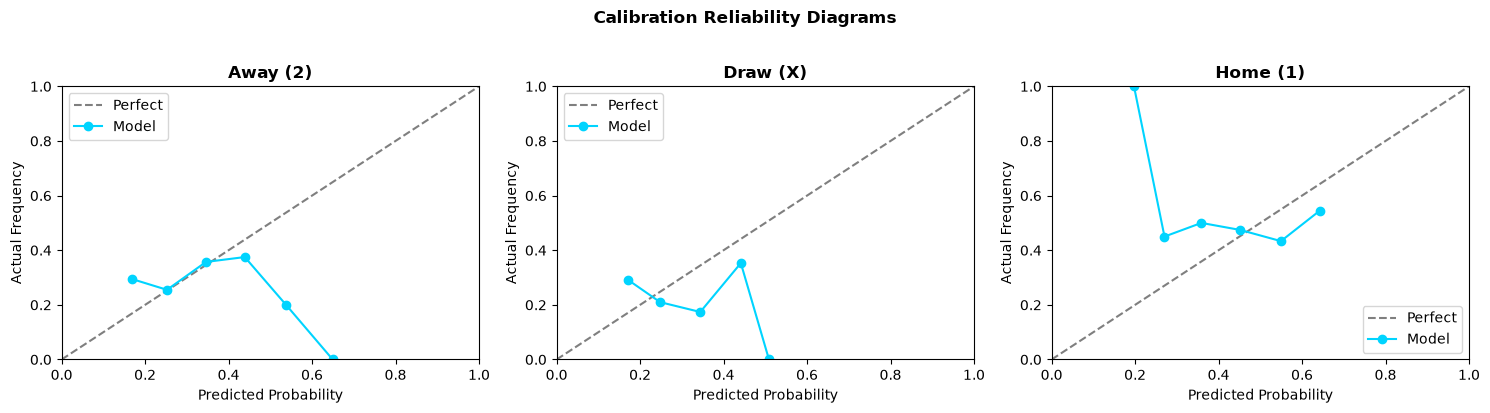

In [4]:
# Calibration reliability diagram
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for cls_idx, cls_name in enumerate(class_names):
    ax = axes[cls_idx]
    probs = ens_probs[:, cls_idx]
    actuals = (y_test == cls_idx).astype(float)
    
    n_bins = 10
    bin_edges = np.linspace(0, 1, n_bins + 1)
    bin_means, bin_true, bin_counts = [], [], []
    
    for i in range(n_bins):
        mask = (probs >= bin_edges[i]) & (probs < bin_edges[i+1])
        if mask.sum() > 0:
            bin_means.append(probs[mask].mean())
            bin_true.append(actuals[mask].mean())
            bin_counts.append(mask.sum())
    
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Perfect')
    ax.plot(bin_means, bin_true, 'o-', color='#00d4ff', label='Model')
    ax.set_title(f'{cls_name}', fontweight='bold')
    ax.set_xlabel('Predicted Probability')
    ax.set_ylabel('Actual Frequency')
    ax.legend()
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

plt.suptitle('Calibration Reliability Diagrams', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

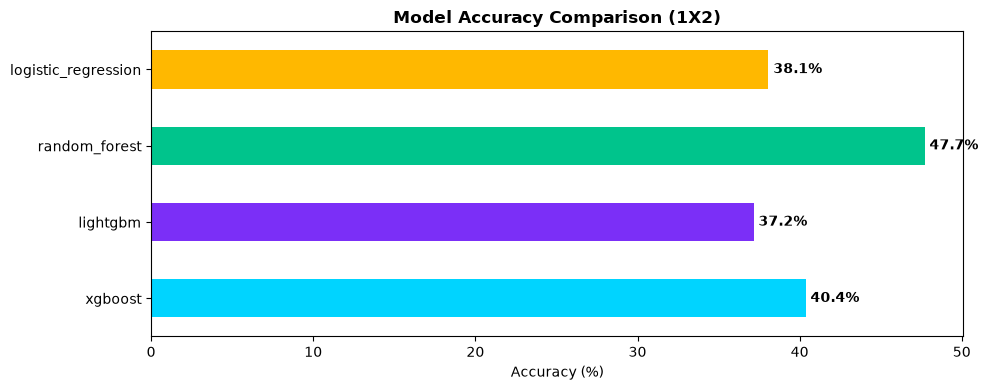

In [5]:
# Per-model accuracy comparison
eval_df = evaluate_models(models, X_test, y_test, '1x2')
eval_df['accuracy_pct'] = eval_df['accuracy'] * 100

fig, ax = plt.subplots(figsize=(10, 4))
colors = ['#00d4ff', '#7b2ff7', '#00c48c', '#ffb800']
eval_df.plot(kind='barh', x='model', y='accuracy_pct', ax=ax,
             color=colors[:len(eval_df)], legend=False)
ax.set_title('Model Accuracy Comparison (1X2)', fontweight='bold')
ax.set_xlabel('Accuracy (%)')
ax.set_ylabel('')
for i, v in enumerate(eval_df['accuracy_pct']):
    ax.text(v + 0.3, i, f'{v:.1f}%', va='center', fontweight='bold')
plt.tight_layout()
plt.show()

In [6]:
# Time-series cross-validation
tscv = TimeSeriesSplit(n_splits=5)
available = [c for c in feature_cols if c in df_feat.columns]
X_all = df_feat[available].values
y_all = df_feat['target_1x2'].values

# Impute for CV
from sklearn.impute import SimpleImputer
imp_cv = SimpleImputer(strategy='median')
X_all_imp = imp_cv.fit_transform(X_all)

fold_accs = []
for fold, (train_idx, test_idx) in enumerate(tscv.split(X_all_imp)):
    mask = ~np.isnan(y_all[train_idx])
    X_tr = X_all_imp[train_idx][mask]
    y_tr = y_all[train_idx][mask]
    
    mask_te = ~np.isnan(y_all[test_idx])
    X_te = X_all_imp[test_idx][mask_te]
    y_te = y_all[test_idx][mask_te]
    
    fold_models = train_all_models(X_tr, y_tr, '1x2')
    probs = build_ensemble_predictions(fold_models, X_te)
    pred = np.argmax(probs, axis=1)
    acc = accuracy_score(y_te, pred)
    fold_accs.append(acc)
    print(f'  Fold {fold+1}: {acc:.4f} (train={len(X_tr)}, test={len(X_te)})')

print(f'\nMean CV Accuracy: {np.mean(fold_accs):.4f} ± {np.std(fold_accs):.4f}')

  Fold 1: 0.4301 (train=379, test=379)
  Fold 2: 0.4512 (train=758, test=379)
  Fold 3: 0.4327 (train=1137, test=379)
  Fold 4: 0.4538 (train=1516, test=379)
  Fold 5: 0.4380 (train=1895, test=379)

Mean CV Accuracy: 0.4412 ± 0.0096
